## Reconstrucción tomográfica con regularización cuadrática


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from funciones import N, xfantoma, matriz_proyeccion


## Inciso a)
def matriz_diferencias(n):
    D = np.zeros((2 * n * (n - 1), n**2))
    fila = 0

    # Diferencias horizontales: X[i, j+1] - X[i, j]
    for i in range(n):
        for j in range(n - 1):
            k = i * n + j ## posición del pixel en el vector
            D[fila, k] = -1
            D[fila, k + 1] = 1
            fila += 1

    # Diferencias verticales: X[i+1, j] - X[i, j]
    for i in range(n - 1):
        for j in range(n):
            k = i * n + j
            D[fila, k] = -1
            D[fila, k + n] = 1
            fila += 1

    return D

n = 8
D = matriz_diferencias(n)
print("Dimensiones obtenidas:", D.shape)

verificacion_filas = np.all((np.sum(D == -1, axis=1) == 1) & (np.sum(D == 1, axis=1) == 1))

print("¿Todas las filas contienen exactamente un -1 y un 1?", verificacion_filas)


Dimensiones obtenidas: (112, 64)
¿Todas las filas contienen exactamente un -1 y un 1? True


In [9]:
## Inciso b)

x_constante = np.ones(n**2) #  representa una imagen en la que todos los píxeles tienen valor 1

Dx_constante = D @ x_constante
Dx_fantoma = D @ xfantoma

print("Dx_constante:", Dx_constante)

print("¿Dx_constante es igual a cero?", np.allclose(Dx_constante, 0) )

print("Norma de Dx_constante:", np.linalg.norm(Dx_constante))
print("Norma de Dxfantoma:", np.linalg.norm(Dx_fantoma))

Dx_constante: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
¿Dx_constante es igual a cero? True
Norma de Dx_constante: 0.0
Norma de Dxfantoma: 2.705549851693737


Cada fila de $D$ calcula la diferencia entre dos píxeles vecinos. Como todos los píxeles de `x_constante` valen $1$, cada diferencia es $1-1=0$. Por eso, $D x_{\text{constante}}$ es el vector nulo y su norma es cero.

En cambio, el fantoma contiene regiones con distintas intensidades. En las fronteras entre estas regiones hay píxeles vecinos diferentes, de modo que algunas componentes de $D x_{\text{fantoma}}$ no son nulas. Por esta razón, $\|D x_{\text{fantoma}}\|>0$.

### Inciso c) Interpretación de la función.

La función está definida por:

$$
J_{\sigma,\lambda}(x)
=
\frac{1}{2}
\left(
\|A_7x-b_\sigma\|^2
+
\lambda\|Dx\|^2
\right).
$$

Esta función permite evaluar qué tan adecuada es una reconstrucción $x$. Está formada por dos términos: el término de ajuste a las mediciones y el término de regularización.

El primer término es

$$
\|A_7x-b_\sigma\|^2.
$$

El vector $A_7x$ contiene las mediciones que produciría la imagen reconstruida $x$, mientras que $b_\sigma$ contiene las mediciones observadas con un nivel de ruido $\sigma$. Por lo tanto, la diferencia $A_7x-b_\sigma$ es el residuo y mide qué tan bien la reconstrucción reproduce las mediciones. Cuanto menor sea su norma, mejor será el ajuste de $x$ a los datos.

El segundo término es

$$
\lambda\|Dx\|^2.
$$

El vector $Dx$ contiene las diferencias entre píxeles vecinos, primero las horizontales y luego las verticales. En consecuencia, $\|Dx\|$ mide la variación total de la imagen entre píxeles vecinos. Una norma pequeña corresponde a una imagen más suave, mientras que una norma grande indica que existen muchos cambios o cambios intensos entre píxeles cercanos.

El parámetro $\lambda$ determina la importancia de la regularización con respecto al ajuste a las mediciones:

- Si *$\lambda=0$*, no se penalizan las diferencias entre píxeles y solamente se intenta ajustar las mediciones. Esto puede hacer que la reconstrucción también reproduzca el ruido.
- Si $\lambda$ es pequeño, se penalizan moderadamente los cambios entre píxeles, buscando reducir el ruido sin perder demasiado detalle.
- Si $\lambda$ es grande, se favorecen imágenes muy suaves. Esto puede reducir las irregularidades causadas por el ruido, pero también puede borrar bordes y detalles reales.
- Si $\lambda$ es excesivamente grande, la reconstrucción puede quedar sobresuavizada o demasiado uniforme.

Por lo tanto, la minimización de $J_{\sigma,\lambda}(x)$ busca un equilibrio entre reproducir correctamente las mediciones y obtener una imagen sin variaciones espaciales excesivas.

In [10]:
# Inciso d)

# Reconstruimos A7 usando las mismas siete direcciones que el ejercicio de ruido
D2 = [(1, 0), (0, 1)]
D4 = D2 + [(1, 1), (1, -1)]
D7 = D4 + [(2, 1), (1, 2), (3, 1)]

A7, rayos7 = matriz_proyeccion(N, D7)
b7 = A7 @ xfantoma

np.random.seed(0)
z = np.random.randn(len(b7))

escala = np.sqrt(np.mean(b7**2))

# Niveles de ruido
sigmas = [0, 0.10, 0.20]

# Mediciones para cada nivel de ruido
mediciones = {}

for sigma in sigmas:
    b_sigma = b7 + sigma * escala * z
    mediciones[sigma] = b_sigma

# Usamos el mismo z y solo cambia la intensidad del ruido(sigma)

In [11]:
# Inciso e)

def costo_J(x, A, b, D, lam):
    return 0.5 * (
        np.linalg.norm(A @ x - b)**2
        + lam * np.linalg.norm(D @ x)**2
    )


def gradiente_descendiente(A, b, D, lam, tasa=0.01, iteraciones=2000):
    # Comenzamos siempre con el vector nulo.
    x = np.zeros(A.shape[1])
    costos = [costo_J(x, A, b, D, lam)]

    for _ in range(iteraciones):
        # Calculamos el gradiente de la función regularizada.
        gradiente = A.T @ (A @ x - b) + lam * D.T @ (D @ x)

        # Actualizamos la reconstrucción.
        x = x - tasa * gradiente
        costos.append(costo_J(x, A, b, D, lam))

    return x, np.array(costos)


In [12]:
sigmas = [0, 0.10, 0.20]
lambdas = [0, 0.1, 0.3, 1]
resultados_e = {}
filas = []

for sigma in sigmas:
    for lam in lambdas:
        x, costos = gradiente_descendiente(
            A7, mediciones[sigma], D, lam
        )

        # Guardamos la reconstrucción y la evolución del costo.
        resultados_e[(sigma, lam)] = {
            "x": x,
            "costos": costos
        }

        # Agregamos los costos de cada combinación a la tabla.
        filas.append({
            "σ": sigma,
            "λ": lam,
            "Costo inicial": costos[0],
            "Costo final": costos[-1]
        })

# Mostramos los resultados en una tabla.
tabla_e = pd.DataFrame(filas)

display(tabla_e.style.format({
    "σ": "{:.2f}",
    "λ": "{:.1f}",
    "Costo inicial": "{:.6f}",
    "Costo final": "{:.6f}"
}))

,σ,λ,Costo inicial,Costo final
0,0.00,0.0,71.515000,0.000000
1,0.00,0.1,71.515000,0.343198
2,0.00,0.3,71.515000,0.928950
3,0.00,1.0,71.515000,2.425972
4,0.10,0.0,74.107425,0.403753
5,0.10,0.1,74.107425,0.778655
6,0.10,0.3,74.107425,1.400083
7,0.10,1.0,74.107425,2.940008
8,0.20,0.0,78.290525,1.615014
9,0.20,0.1,78.290525,2.084714


Adaptamos el método de gradiente descendiente utilizando el gradiente

$$
\nabla J_{\sigma,\lambda}(x)
= A_7^T(A_7x-b_\sigma)+\lambda D^TDx.
$$

Aplicamos el método a las 12 combinaciones de
$\sigma \in \{0, 0.10, 0.20\}$ y $\lambda \in \{0, 0.1, 0.3, 1\}$,
comenzando siempre con $x_0=0$.

En esta implementación utilizamos una tasa fija de $0.01$ y realizamos
2000 iteraciones. Guardamos las reconstrucciones y la evolución del costo
para cada combinación.

In [13]:
# Inciso f)

def gradiente_descendiente_f(A, b, D, lam, tasa, tol=1e-6, max_iter=10000):
    # Comenzamos siempre con el vector nulo.
    x = np.zeros(A.shape[1])
    costos = [costo_J(x, A, b, D, lam)]

    # Definimos la tolerancia respecto de la norma del gradiente inicial.
    norma_inicial = np.linalg.norm(A.T @ (-b))
    umbral = tol * max(1.0, norma_inicial)

    for k in range(max_iter + 1):
        gradiente = A.T @ (A @ x - b) + lam * D.T @ (D @ x)

        # Detenemos el método cuando el gradiente es suficientemente pequeño.
        if np.linalg.norm(gradiente) <= umbral:
            return x, np.array(costos), k, "Convergencia"

        if k == max_iter:
            return x, np.array(costos), k, "Máximo de iteraciones"

        x_nuevo = x - tasa * gradiente
        costo_nuevo = costo_J(x_nuevo, A, b, D, lam)

        # Descartamos la tasa si el costo aumenta o deja de ser finito.
        # Admitimos una pequeña tolerancia por redondeo numérico.
        margen = 1e-12 * max(1.0, costos[-1])

        if not np.isfinite(costo_nuevo) or costo_nuevo > costos[-1] + margen:
            return x, np.array(costos), k, "Descenso inestable"

        x = x_nuevo
        costos.append(costo_nuevo)


tasas = [0.005, 0.01, 0.02, 0.04, 0.06]
resultados_f = {}
filas_f = []

# Comparamos las tasas usando las mismas mediciones en cada combinación.
for tasa in tasas:
    for sigma in sigmas:
        for lam in lambdas:
            x, costos, iteraciones, estado = gradiente_descendiente_f(
                A7, mediciones[sigma], D, lam, tasa
            )

            resultados_f[(tasa, sigma, lam)] = {
                "x": x,
                "costos": costos,
                "estado": estado
            }

            filas_f.append({
                "Tasa": tasa,
                "σ": sigma,
                "λ": lam,
                "Iteraciones": iteraciones,
                "Costo final": costos[-1],
                "Estado": estado
            })

tabla_f = pd.DataFrame(filas_f)

# Resumimos el desempeño de cada tasa en las 12 combinaciones.
resumen_f = (
    tabla_f.groupby("Tasa", as_index=False)
    .agg(
        Convergencias=("Estado", lambda estados: (estados == "Convergencia").sum()),
        Inestables=("Estado", lambda estados: (estados == "Descenso inestable").sum()),
        Iteraciones_totales=("Iteraciones", "sum")
    )
)

display(resumen_f.style.format({"Tasa": "{:.3f}"}))

# Elegimos entre las tasas que convergieron de forma estable en todos los casos.
cantidad_casos = len(sigmas) * len(lambdas)
candidatas = resumen_f[
    resumen_f["Convergencias"] == cantidad_casos
]

if not candidatas.empty:
    tasa_elegida = candidatas.loc[
        candidatas["Iteraciones_totales"].idxmin(), "Tasa"
    ]
    print(f"Seleccionamos la tasa {tasa_elegida:.3f}.")

    # Mostramos los resultados correspondientes a la tasa seleccionada.
    display(
        tabla_f[tabla_f["Tasa"] == tasa_elegida]
        .reset_index(drop=True)
        .style.format({
            "Tasa": "{:.3f}",
            "σ": "{:.2f}",
            "λ": "{:.1f}",
            "Costo final": "{:.6f}"
        })
    )
else:
    print("No encontramos una tasa que converja en todas las combinaciones.")

,Tasa,Convergencias,Inestables,Iteraciones_totales
0,0.005,12,0,18011
1,0.010,12,0,8985
2,0.020,12,0,4472
3,0.040,12,0,2214
4,0.060,0,12,0


Seleccionamos la tasa 0.040.


,Tasa,σ,λ,Iteraciones,Costo final,Estado
0,0.040,0.00,0.0,318,0.000000,Convergencia
1,0.040,0.00,0.1,210,0.343198,Convergencia
2,0.040,0.00,0.3,128,0.928950,Convergencia
3,0.040,0.00,1.0,58,2.425972,Convergencia
4,0.040,0.10,0.0,319,0.403753,Convergencia
5,0.040,0.10,0.1,216,0.778655,Convergencia
6,0.040,0.10,0.3,134,1.400083,Convergencia
7,0.040,0.10,1.0,62,2.940008,Convergencia
8,0.040,0.20,0.0,339,1.615014,Convergencia
9,0.040,0.20,0.1,227,2.084714,Convergencia



Evaluamos las tasas de aprendizaje
$\alpha \in \{0.005, 0.01, 0.02, 0.04, 0.06\}$
para las 12 combinaciones de ruido y regularización, comenzando
siempre con $x_0=0$.

Establecimos un máximo de 10000 iteraciones e incorporamos el siguiente
criterio de parada:

$$
\|\nabla J_{\sigma,\lambda}(x_k)\|
\leq 10^{-6}\max\left\{1,\|\nabla J_{\sigma,\lambda}(x_0)\|\right\}.
$$

Además, verificamos que el costo no aumentara durante las iteraciones,
admitiendo una pequeña tolerancia por redondeo numérico.

Entre las tasas que alcanzan la tolerancia con descenso estable en todas
las combinaciones, seleccionamos la que requiere menos iteraciones totales.
No utilizamos el error respecto del fantoma para seleccionar la tasa
ni para detener el método.

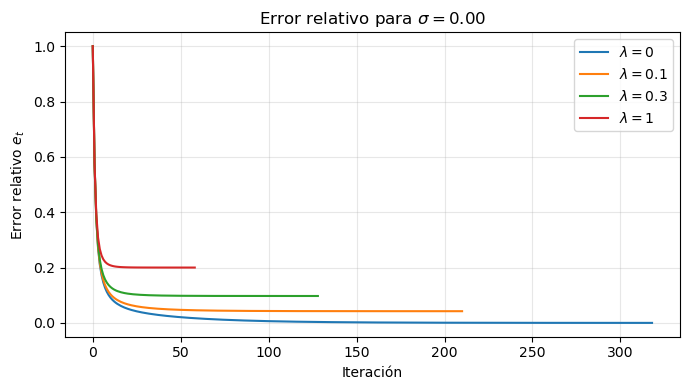

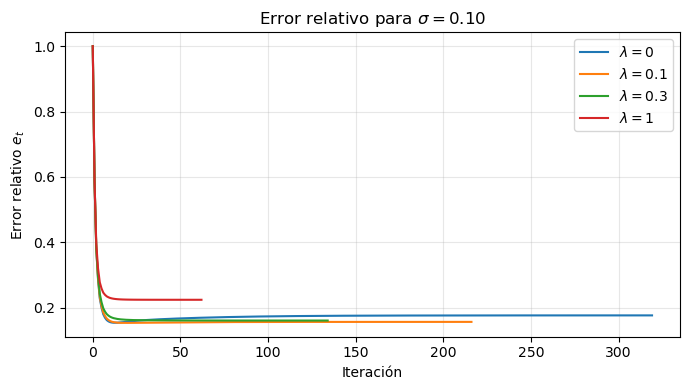

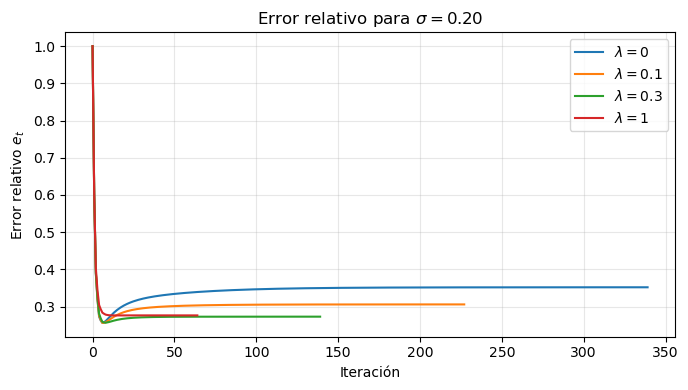

In [14]:
# Inciso g)

# Recuperamos la tasa seleccionada en f) y repetimos sus pasos aceptados.
if candidatas.empty:
    raise ValueError("Primero debe converger alguna de las tasas del inciso f).")

tasa_elegida = candidatas.loc[
    candidatas["Iteraciones_totales"].idxmin(), "Tasa"
]
resultados_g = {}
norma_fantoma = np.linalg.norm(xfantoma)

for sigma in sigmas:
    for lam in lambdas:
        resultado_f = resultados_f[(tasa_elegida, sigma, lam)]
        x = np.zeros(A7.shape[1])
        errores = [np.linalg.norm(x - xfantoma) / norma_fantoma]

        # El historial de costos incluye x_0: hay un paso menos que costos.
        # El error solo se registra; no interviene en el criterio de parada.
        for _ in range(len(resultado_f["costos"]) - 1):
            gradiente = A7.T @ (A7 @ x - mediciones[sigma]) + lam * D.T @ (D @ x)
            x = x - tasa_elegida * gradiente
            errores.append(np.linalg.norm(x - xfantoma) / norma_fantoma)

        resultados_g[(sigma, lam)] = {
            "x": x,
            "errores": np.array(errores),
            "costos": resultado_f["costos"],
            "estado": resultado_f["estado"]
        }

import matplotlib.pyplot as plt

# Generamos un gráfico separado para cada nivel de ruido.
for sigma in sigmas:
    plt.figure(figsize=(7, 4))

    for lam in lambdas:
        errores = resultados_g[(sigma, lam)]["errores"]
        plt.plot(errores, label=fr"$\lambda={lam}$")

    plt.title(fr"Error relativo para $\sigma={sigma:.2f}$")
    plt.xlabel("Iteración")
    plt.ylabel(r"Error relativo $e_t$")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Evolución del error relativo

Registramos el error relativo durante las iteraciones y comparamos los
distintos valores de $\lambda$ en un gráfico para cada nivel de ruido.
Todas las curvas comienzan en $e_0=1$, ya que partimos de $x_0=0$.

**Sin ruido ($\sigma=0$)**, observamos que la reconstrucción sin
regularización ($\lambda=0$) alcanza un error prácticamente nulo.
Al aumentar $\lambda$, el error final aumenta: la penalización de las
diferencias entre píxeles favorece imágenes más suaves, pero modifica
detalles del fantoma incluso cuando las mediciones no contienen ruido.

**Con ruido moderado ($\sigma=0.10$)**, observamos que una regularización
pequeña resulta beneficiosa. Entre los valores evaluados, $\lambda=0.1$
obtiene el menor error final. Sin regularización, el error disminuye
inicialmente, alcanza un mínimo y luego aumenta, aunque el costo siga
descendiendo. Esto ocurre porque ajustar mejor las mediciones también
puede implicar reproducir parte del ruido.

**Con mayor ruido ($\sigma=0.20$)**, este aumento del error después de
las primeras iteraciones se vuelve más marcado para valores pequeños
de $\lambda$. Entre los valores evaluados, $\lambda=0.3$ obtiene el
menor error final. La regularización ayuda a reducir el efecto del ruido,
aunque un valor mayor no garantiza una mejor reconstrucción, porque
también puede suavizar demasiado los detalles.

Estos resultados nos muestran que reducir el costo no implica
necesariamente reducir el error respecto del fantoma. Utilizamos este
error únicamente para analizar las reconstrucciones; mantuvimos el
criterio de parada del inciso f), basado en la norma del gradiente y
en una cantidad máxima de iteraciones.

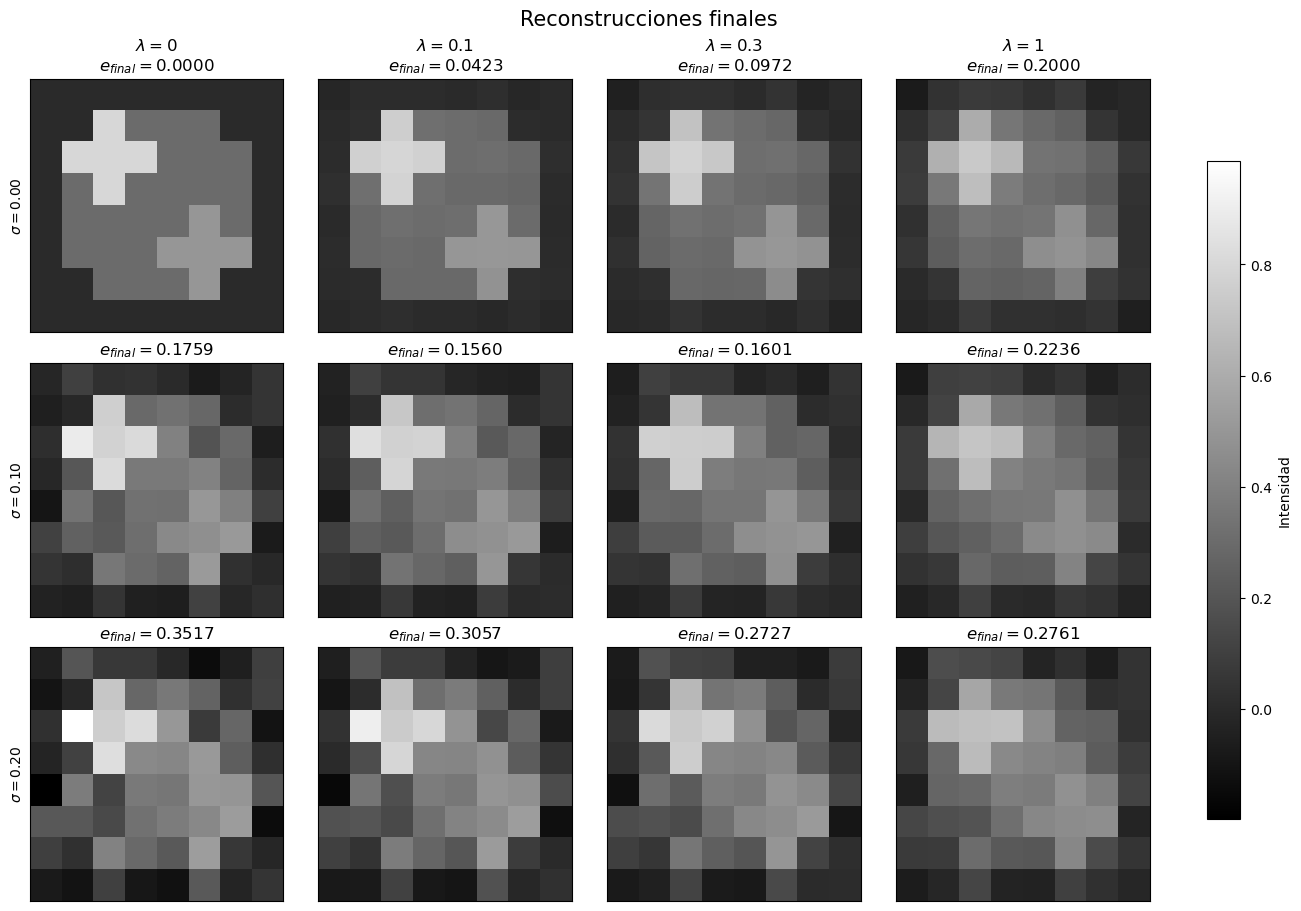

In [15]:
# Inciso h)

# Calculamos límites comunes a partir de todas las reconstrucciones.
vmin = min(r["x"].min() for r in resultados_g.values())
vmax = max(r["x"].max() for r in resultados_g.values())

fig, ejes = plt.subplots(len(sigmas), len(lambdas), figsize=(13, 9), constrained_layout=True)

for i, sigma in enumerate(sigmas):
    for j, lam in enumerate(lambdas):
        resultado = resultados_g[(sigma, lam)]
        reconstruccion = resultado["x"].reshape(N, N)
        error = resultado["errores"][-1]

        ax = ejes[i, j]

        # Usamos la misma escala de color en todos los paneles.
        imagen = ax.imshow(
            reconstruccion,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(fr"$e_{{final}}={error:.4f}$")

        # Indicamos los valores de cada fila y columna.
        if i == 0:
            ax.set_title(
                fr"$\lambda={lam}$" + "\n"
                + fr"$e_{{final}}={error:.4f}$"
            )

        if j == 0:
            ax.set_ylabel(fr"$\sigma={sigma:.2f}$")

        ax.set_xticks([])
        ax.set_yticks([])

# Agregamos una barra de color compartida.
fig.colorbar(
    imagen, ax=ejes.ravel().tolist(),
    label="Intensidad", shrink=0.8
)

fig.suptitle("Reconstrucciones finales", fontsize=15)
plt.show()

### Comparación de las reconstrucciones finales

Organizamos las reconstrucciones en una grilla donde cada fila corresponde
a un nivel de ruido $\sigma$ y cada columna a un valor de regularización
$\lambda$. Sobre cada imagen indicamos su error relativo final.

Utilizamos los mismos límites de color en todos los paneles, calculados
a partir del mínimo y el máximo globales de las reconstrucciones.
De esta manera, un mismo tono representa la misma intensidad en toda
la grilla y podemos comparar las imágenes sin que el ajuste automático
del contraste oculte sus diferencias.

Al recorrer cada fila, podemos evaluar cómo cambia la reconstrucción
al aumentar la regularización. Al recorrer cada columna, podemos comparar
el efecto del ruido manteniendo fijo $\lambda$. Complementamos esta
comparación visual con los errores relativos indicados sobre las imágenes.

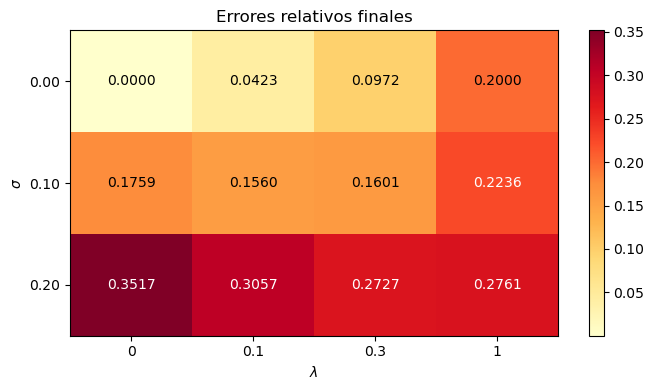

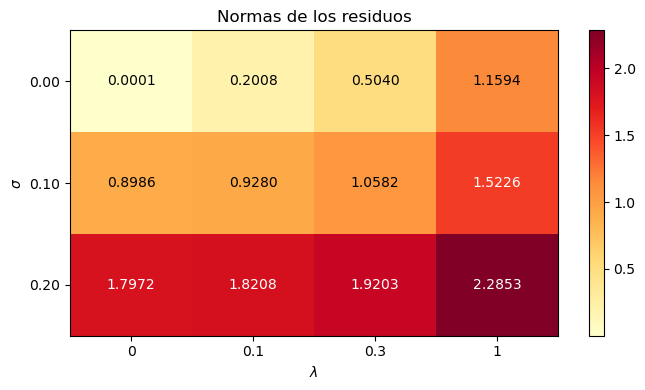

In [16]:
# Inciso i)

filas_i = []

for sigma in sigmas:
    for lam in lambdas:
        resultado = resultados_g[(sigma, lam)]
        x = resultado["x"]

        # Registramos el error final y la norma del residuo.
        filas_i.append({
            "σ": sigma,
            "λ": lam,
            "Error relativo": resultado["errores"][-1],
            "Norma del residuo": np.linalg.norm(
                A7 @ x - mediciones[sigma]
            )
        })

tabla_i = pd.DataFrame(filas_i)

tabla_errores = tabla_i.pivot(
    index="σ", columns="λ", values="Error relativo"
)
tabla_residuos = tabla_i.pivot(
    index="σ", columns="λ", values="Norma del residuo"
)

# Generamos un mapa de calor para cada medida.
for tabla, titulo in [
    (tabla_errores, "Errores relativos finales"),
    (tabla_residuos, "Normas de los residuos")
]:
    fig, ax = plt.subplots(figsize=(7, 4))

    imagen = ax.imshow(
        tabla.to_numpy(),
        cmap="YlOrRd",
        aspect="auto"
    )

    ax.set_xticks(range(len(tabla.columns)))
    ax.set_xticklabels([f"{lam:g}" for lam in tabla.columns])
    ax.set_yticks(range(len(tabla.index)))
    ax.set_yticklabels([f"{sigma:.2f}" for sigma in tabla.index])

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\sigma$")
    ax.set_title(titulo)

    # Escribimos el valor de cada celda sobre su color.
    for i in range(len(tabla.index)):
        for j in range(len(tabla.columns)):
            valor = tabla.iloc[i, j]
            color = "white" if imagen.norm(valor) > 0.6 else "black"

            ax.text(
                j, i, f"{valor:.4f}",
                ha="center", va="center", color=color
            )

    fig.colorbar(imagen, ax=ax)
    plt.tight_layout()
    plt.show()


### Inciso i) Comparación de errores y residuos

Resumimos los errores relativos finales y las normas de los residuos
$\|A_7x-b_\sigma\|_2$ en dos tablas, con una fila por cada nivel de ruido
y una columna por cada valor de regularización.

Entre los valores evaluados, obtuvimos el menor error final con
$\lambda=0$ para $\sigma=0$, con $\lambda=0.1$ para $\sigma=0.10$
y con $\lambda=0.3$ para $\sigma=0.20$.

Sin ruido, la regularización no mejora la reconstrucción. En cambio,
cuando agregamos ruido, una regularización moderada permite reducir
el error respecto del fantoma.

La norma del residuo mide qué tan bien reproducimos las mediciones,
mientras que el error relativo mide qué tan cerca estamos del fantoma.
Por eso, un residuo menor no garantiza una reconstrucción mejor:
también podemos estar ajustando el ruido de las mediciones.

Seleccionamos estos valores de $\lambda$ comparando los errores finales
una vez terminadas las ejecuciones, sin utilizar el fantoma en el
criterio de parada.

### Inciso j)

**¿En qué casos mejoró la reconstrucción al regularizar?**

Sin ruido ($\sigma=0$), obtuvimos el menor error con $\lambda=0$,
con una reconstrucción prácticamente exacta. En este caso, la
regularización aumentó el error al suavizar detalles del fantoma.

Para $\sigma=0.10$, la regularización mejoró la reconstrucción con
$\lambda=0.1$ y $\lambda=0.3$: los errores fueron aproximadamente
$0.1560$ y $0.1601$, frente a $0.1759$ sin regularización.
Sin embargo, con $\lambda=1$ el error aumentó a $0.2236$.

Para $\sigma=0.20$, todos los valores positivos de $\lambda$ evaluados
mejoraron el resultado obtenido con $\lambda=0$. El menor error fue
$0.2727$, con $\lambda=0.3$, frente a $0.3517$ sin regularización.

**¿Cómo cambió el valor más conveniente de $\lambda$ al aumentar el ruido?**

Entre los valores evaluados, el más conveniente pasó de $\lambda=0$
sin ruido a $\lambda=0.1$ con ruido moderado y a $\lambda=0.3$ con
mayor ruido. Observamos que, al aumentar el ruido, resultó beneficioso
dar más importancia a la suavidad de la imagen para reducir el ajuste
a las perturbaciones de las mediciones.

**¿Qué efecto produjo una regularización excesiva?**

Una regularización demasiado intensa suavizó los bordes y redujo el
contraste entre regiones, perdiendo detalles del fantoma. Con
$\lambda=1$ obtuvimos un error mayor que con el mejor valor de
$\lambda$ en los tres niveles de ruido.

Para $\sigma=0.20$, $\lambda=1$ todavía mejoró la reconstrucción sin
regularización, pero fue ligeramente peor que $\lambda=0.3$.
Por lo tanto, aumentar la regularización no siempre mejora el resultado:
necesitamos equilibrar la reducción del ruido con la conservación
de los detalles de la imagen.